In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
import re
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.model_selection import train_test_split

BASE_DIR = Path().resolve().parent
shap.initjs()

In [2]:
data = pd.read_csv(BASE_DIR / "data" / "processed" / "processed_train.csv")
data.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in data.columns]

X = data.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = data['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model = joblib.load(BASE_DIR / "models" / "best_model.pkl")

print(f"Data loaded: {X_test.shape}")
print(f"Model loaded successfully")

Data loaded: (61503, 193)
Model loaded successfully


In [3]:

X_sample = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed successfully")
print(f"SHAP values shape: {np.array(shap_values).shape}")

SHAP values computed successfully
SHAP values shape: (1000, 193)


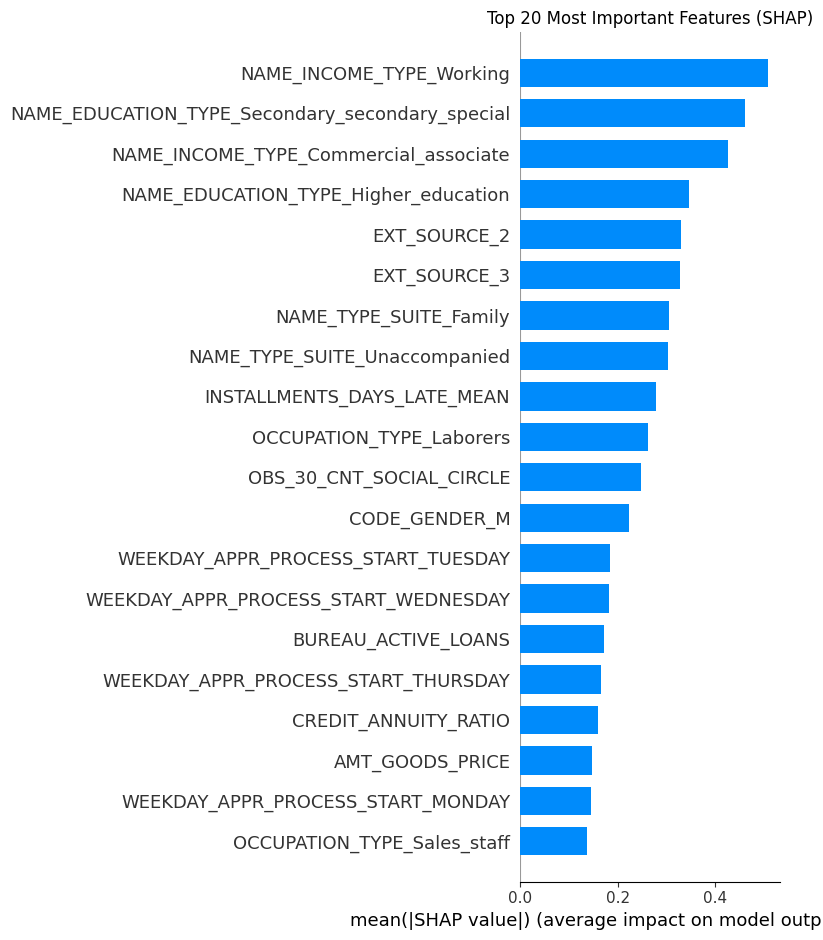

In [4]:
plt.figure()
shap.summary_plot(
    shap_values, 
    X_sample, 
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Top 20 Most Important Features (SHAP)")
plt.tight_layout()
plt.savefig('../reports/figures/shap_feature_importance.png', 
            bbox_inches='tight')
plt.show()

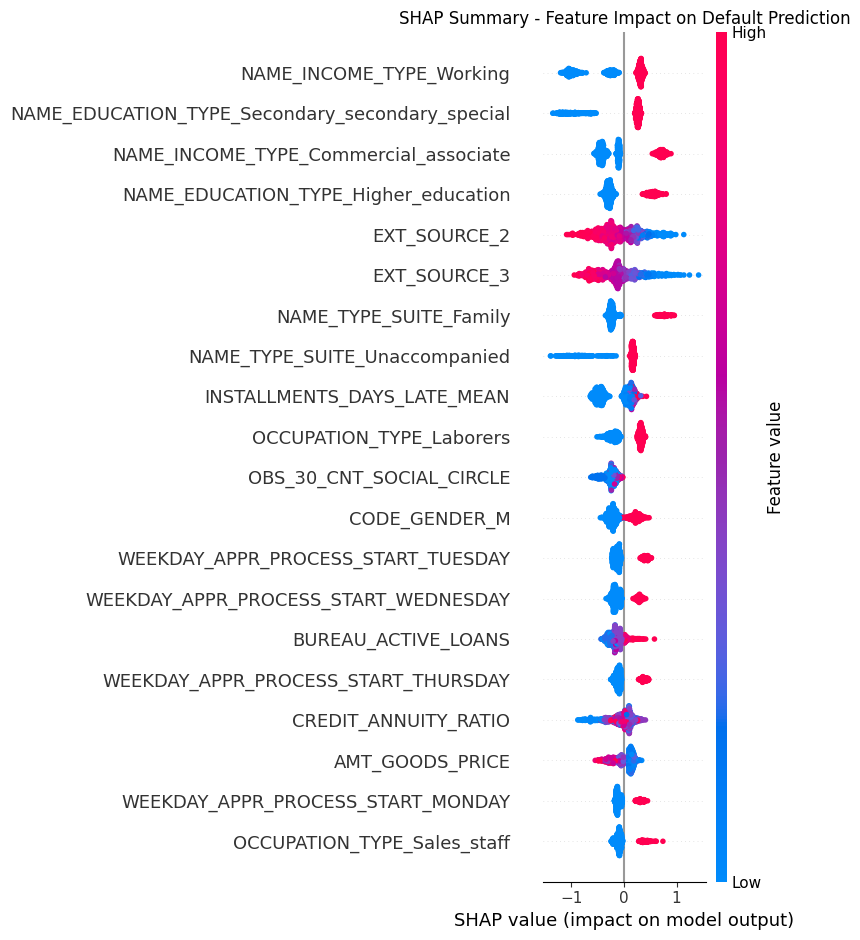

In [5]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,
    show=False
)
plt.title("SHAP Summary - Feature Impact on Default Prediction")
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_dot.png', 
            bbox_inches='tight')
plt.show()

In [6]:

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

feature_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'SHAP_Importance': np.abs(shap_vals).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

Top 15 Most Important Features:
                                        Feature  SHAP_Importance
                       NAME_INCOME_TYPE_Working         0.506989
NAME_EDUCATION_TYPE_Secondary_secondary_special         0.460539
          NAME_INCOME_TYPE_Commercial_associate         0.424972
           NAME_EDUCATION_TYPE_Higher_education         0.346549
                                   EXT_SOURCE_2         0.329512
                                   EXT_SOURCE_3         0.326534
                         NAME_TYPE_SUITE_Family         0.303969
                  NAME_TYPE_SUITE_Unaccompanied         0.303723
                    INSTALLMENTS_DAYS_LATE_MEAN         0.278433
                       OCCUPATION_TYPE_Laborers         0.261468
                       OBS_30_CNT_SOCIAL_CIRCLE         0.246886
                                  CODE_GENDER_M         0.222655
             WEEKDAY_APPR_PROCESS_START_TUESDAY         0.184719
           WEEKDAY_APPR_PROCESS_START_WEDNESDAY         0.

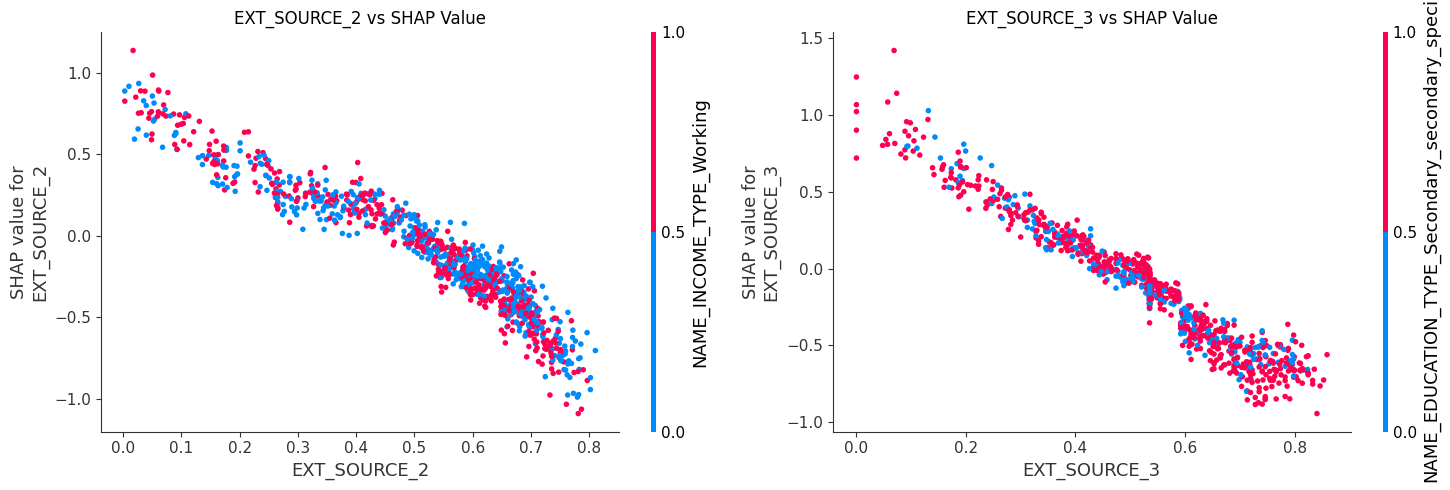

In [7]:
ext_features = [col for col in X_sample.columns if 'EXT_SOURCE' in col]

fig, axes = plt.subplots(1, len(ext_features), figsize=(15, 5))

for i, feature in enumerate(ext_features):
    feature_idx = list(X_sample.columns).index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_vals,
        X_sample,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'{feature} vs SHAP Value')

plt.tight_layout()
plt.savefig('../reports/figures/shap_ext_source_dependence.png',
            bbox_inches='tight')
plt.show()

BORROWER 1 - Predicted as HIGH RISK (Defaulter)


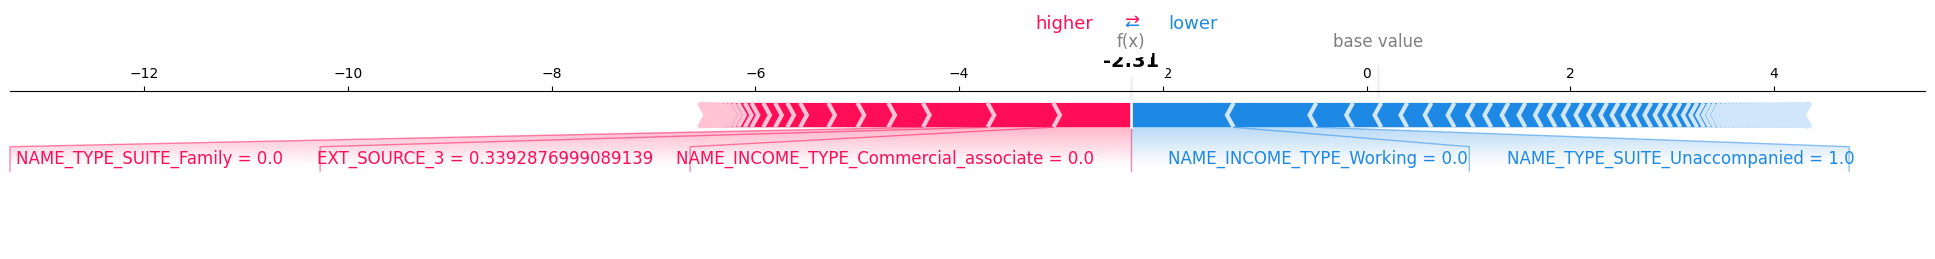

In [8]:

defaulter_idx = np.where(y_test.values == 1)[0][0]
non_defaulter_idx = np.where(y_test.values == 0)[0][0]

X_test_reset = X_test.reset_index(drop=True)

print("=" * 50)
print("BORROWER 1 - Predicted as HIGH RISK (Defaulter)")
print("=" * 50)
shap.force_plot(
    explainer.expected_value if not isinstance(explainer.expected_value, list) 
    else explainer.expected_value[1],
    shap_vals[defaulter_idx],
    X_test_reset.iloc[defaulter_idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig('../reports/figures/shap_force_defaulter.png',
            bbox_inches='tight')
plt.show()

BORROWER 2 - Predicted as LOW RISK (Non-Defaulter)


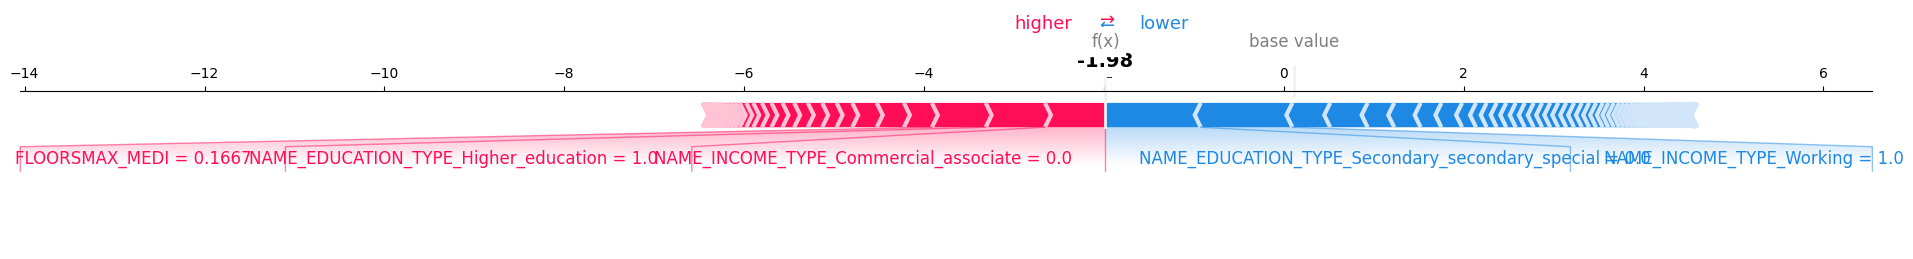

In [9]:

print("BORROWER 2 - Predicted as LOW RISK (Non-Defaulter)")
shap.force_plot(
    explainer.expected_value if not isinstance(explainer.expected_value, list) 
    else explainer.expected_value[1],
    shap_vals[non_defaulter_idx],
    X_test_reset.iloc[non_defaulter_idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig('../reports/figures/shap_force_non_defaulter.png',
            bbox_inches='tight')
plt.show()

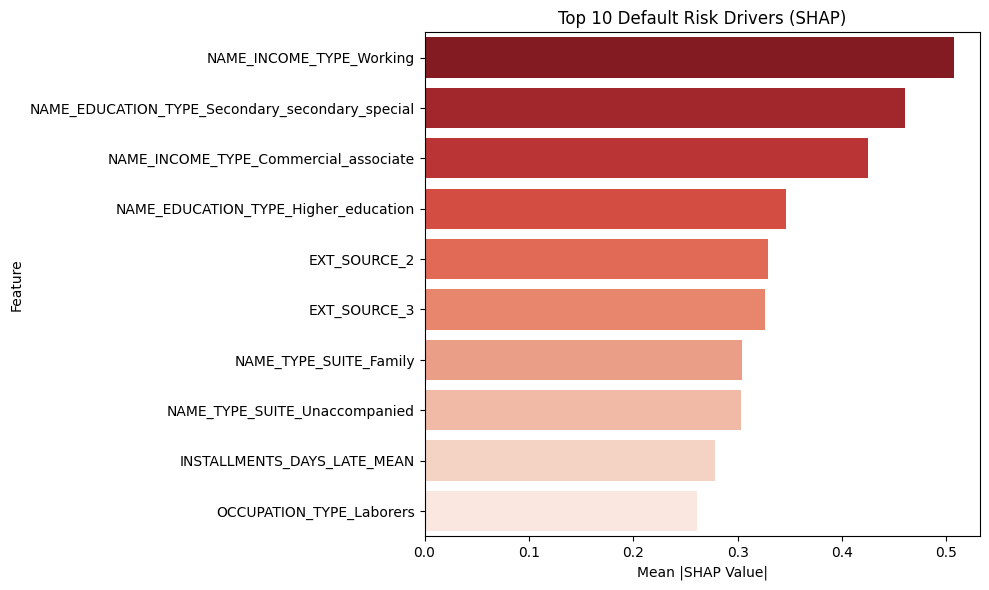


Business Interpretation:
--------------------------------------------------
  NAME_INCOME_TYPE_Working                 0.5070
  NAME_EDUCATION_TYPE_Secondary_secondary_special 0.4605
  NAME_INCOME_TYPE_Commercial_associate    0.4250
  NAME_EDUCATION_TYPE_Higher_education     0.3465
  EXT_SOURCE_2                             0.3295
  EXT_SOURCE_3                             0.3265
  NAME_TYPE_SUITE_Family                   0.3040
  NAME_TYPE_SUITE_Unaccompanied            0.3037
  INSTALLMENTS_DAYS_LATE_MEAN              0.2784
  OCCUPATION_TYPE_Laborers                 0.2615


In [10]:
top_10 = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='SHAP_Importance', y='Feature', data=top_10, palette='Reds_r')
plt.title('Top 10 Default Risk Drivers (SHAP)')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('../reports/figures/top10_risk_drivers.png',
            bbox_inches='tight')
plt.show()

print("\nBusiness Interpretation:")
print("-" * 50)
for _, row in top_10.iterrows():
    print(f"  {row['Feature']:<40} {row['SHAP_Importance']:.4f}")